<a href="https://colab.research.google.com/github/jasminewongjiaxuan/marketing-campaign-response-prediction/blob/main/marketing_campaign_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving marketing_campaign.csv to marketing_campaign (1).csv


1. Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

2. Load dataset

In [ ]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [ ]:
print(df.shape)

(2240, 29)


3.3.1 Handling Missing Values

In [ ]:
print("\nMissing values before handling:")
print(df.isnull().sum())

df["Income"] = df["Income"].fillna(0)

print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values before handling:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Missing values after handling:
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome          

3.3.2 Removing Identifier Column

In [ ]:
if "ID" in df.columns:
    df.drop("ID", axis=1, inplace=True)

print("\nColumns after dropping ID:")
print(df.columns)


Columns after dropping ID:
Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')


3.3.3 Data Type and Datetime Conversion

In [ ]:
print("\nData types before conversion:")
print(df.dtypes)

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y", errors="coerce")

print("\nData types after conversion:")
print(df.dtypes)



Data types before conversion:
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

Data types after conversion:
Year_Birth                      int64
Education          

3.3.4 Feature Engineering

In [ ]:
df["Total_Campaign_Accepted"] = (
    df["AcceptedCmp1"] +
    df["AcceptedCmp2"] +
    df["AcceptedCmp3"] +
    df["AcceptedCmp4"] +
    df["AcceptedCmp5"]
)

df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

df["Total_Spend"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

df["Age"] = 2025 - df["Year_Birth"]

reference_date = df["Dt_Customer"].max()
df["Customer_Days"] = (reference_date - df["Dt_Customer"]).dt.days

print("\nDataset after feature engineering:")
print(df.head())


Dataset after feature engineering:
   Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0        1957  Graduation         Single  58138.0        0         0   
1        1954  Graduation         Single  46344.0        1         1   
2        1965  Graduation       Together  71613.0        0         0   
3        1984  Graduation       Together  26646.0        1         0   
4        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  MntFruits  ...  AcceptedCmp2  Complain  \
0  2012-09-04       58       635         88  ...             0         0   
1  2014-03-08       38        11          1  ...             0         0   
2  2013-08-21       26       426         49  ...             0         0   
3  2014-02-10       26        11          4  ...             0         0   
4  2014-01-19       94       173         43  ...             0         0   

   Z_CostContact  Z_Revenue  Response  Total_Campaign_Accepted  \
0       

3.3.5 Removing Irrelevant Variables

In [ ]:
irrelevant_cols = ["Z_CostContact", "Z_Revenue", "Complain"]
df.drop(columns=[col for col in irrelevant_cols if col in df.columns], inplace=True)

print("\nColumns after dropping irrelevant variables:")
print(df.columns)


Columns after dropping irrelevant variables:
Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Total_Campaign_Accepted', 'Total_Children',
       'Total_Spend', 'Age', 'Customer_Days'],
      dtype='object')


3.3.6 Handling Duplicate Records

In [ ]:
print("\nDuplicate rows before removing:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after removing:", df.duplicated().sum())
print("Dataset shape after removing duplicates:", df.shape)


Duplicate rows before removing: 182
Duplicate rows after removing: 0
Dataset shape after removing duplicates: (2058, 30)


3.3.7 Removing Redundant Variables

In [ ]:
redundant_cols = [
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5",
    "Kidhome", "Teenhome",
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    "Year_Birth", "Dt_Customer"
]

df.drop(columns=[col for col in redundant_cols if col in df.columns], inplace=True)

print("\nColumns after dropping redundant variables:")
print(df.columns)
print("Dataset shape:", df.shape)


Columns after dropping redundant variables:
Index(['Education', 'Marital_Status', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Response', 'Total_Campaign_Accepted',
       'Total_Children', 'Total_Spend', 'Age', 'Customer_Days'],
      dtype='object')
Dataset shape: (2058, 15)


3.3.8 Feature Selection


Feature importance:
                    Feature  Importance
0                   Recency    0.128759
1   Total_Campaign_Accepted    0.121688
2             Customer_Days    0.117004
3               Total_Spend    0.114491
4                    Income    0.097913
5                       Age    0.071460
6         NumStorePurchases    0.056650
7       NumCatalogPurchases    0.054494
8           NumWebPurchases    0.049409
9         NumWebVisitsMonth    0.049330
10           Marital_Status    0.039589
11        NumDealsPurchases    0.037005
12                Education    0.033313
13           Total_Children    0.028897


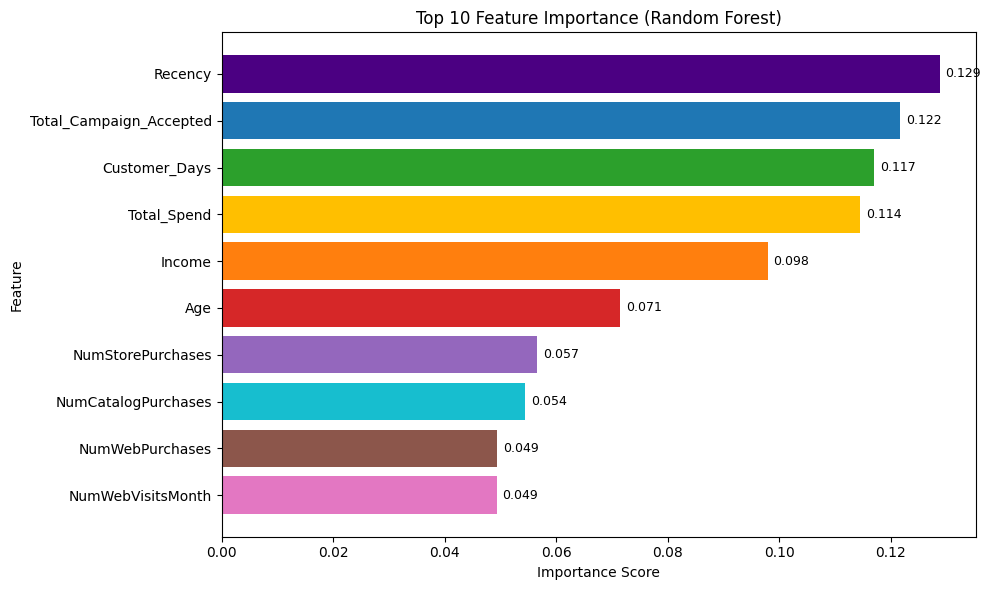

In [ ]:
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

df_fs = df.copy()

if "Response_Label" in df_fs.columns:
    df_fs = df_fs.drop("Response_Label", axis=1)

label_encoders = {}
categorical_cols_fs = df_fs.select_dtypes(include=["object"]).columns

for col in categorical_cols_fs:
    le = LabelEncoder()
    df_fs[col] = le.fit_transform(df_fs[col])
    label_encoders[col] = le


X_fs = df_fs.drop("Response", axis=1)
y_fs = df_fs["Response"]

rf_fs = RandomForestClassifier(random_state=42)
rf_fs.fit(X_fs, y_fs)

feature_importance = pd.DataFrame({
    "Feature": X_fs.columns,
    "Importance": rf_fs.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature importance:")
print(feature_importance)

top10_features = feature_importance.head(10)

colors = [
    "#4B0082",  # purple
    "#1f77b4",  # blue
    "#2ca02c",  # green
    "#ffbf00",  # yellow
    "#ff7f0e",  # orange
    "#d62728",  # red
    "#9467bd",  # violet
    "#17becf",  # cyan
    "#8c564b",  # brown
    "#e377c2"   # pink
]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top10_features["Feature"],
    top10_features["Importance"],
    color=colors[:len(top10_features)]
)

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=9
    )

plt.title("Top 10 Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
os.makedirs("chapter4_figures", exist_ok=True)
plt.savefig("chapter4_figures/Figure_4_10_Top_10_Feature_Importance.png", dpi=300)
plt.show()

3.3.9 Encoding Categorical Variables

In [ ]:
X = df.drop("Response", axis=1)
y = df["Response"]

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ]
)

print("\nPreprocessor:")
print(preprocessor)


Numerical columns: ['Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Total_Campaign_Accepted', 'Total_Children', 'Total_Spend', 'Age', 'Customer_Days']
Categorical columns: ['Education', 'Marital_Status']

Preprocessor:
ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Income', 'Recency', 'NumDealsPurchases',
                                  'NumWebPurchases', 'NumCatalogPurchases',
                                  'NumStorePurchases', 'NumWebVisitsMonth',
                                  'Total_Campaign_Accepted', 'Total_Children',
                                  'Total_Spend', 'Age', 'Customer_Days']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['Education', 'Marital_Status'])])


3.4 Data Splitting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("\nTrain and test shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


Train and test shapes:
X_train: (1440, 14)
X_test: (618, 14)
y_train: (1440,)
y_test: (618,)


3.5 Feature Scaling

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\nProcessed train and test shapes:")
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed:", X_test_processed.shape)


Processed train and test shapes:
X_train_processed: (1440, 23)
X_test_processed: (618, 23)


3.6.3	Logistic Regression

In [ ]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("\nLogistic Regression Results")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_lr, zero_division=0))
print("F1-Score:", f1_score(y_test, y_pred_lr, zero_division=0))


Logistic Regression Results
ROC-AUC: 0.8972307942179634
Accuracy: 0.9029126213592233
Precision: 0.7833333333333333
Recall: 0.5
F1-Score: 0.6103896103896104


3.6.4	Naive Bayes

In [ ]:
X_train_nb = preprocessor.fit_transform(X_train)
X_test_nb = preprocessor.transform(X_test)

if hasattr(X_train_nb, "toarray"):
    X_train_nb = X_train_nb.toarray()
    X_test_nb = X_test_nb.toarray()

nb_model = GaussianNB()
nb_model.fit(X_train_nb, y_train)

y_pred_nb = nb_model.predict(X_test_nb)
y_prob_nb = nb_model.predict_proba(X_test_nb)[:, 1]

print("\nNaive Bayes Results")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_nb, zero_division=0))
print("F1-Score:", f1_score(y_test, y_pred_nb, zero_division=0))


Naive Bayes Results
ROC-AUC: 0.8375629364950464
Accuracy: 0.8656957928802589
Precision: 0.72
Recall: 0.19148936170212766
F1-Score: 0.3025210084033613


3.6.5	K-Nearest Neighbors (KNN)

In [ ]:
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

knn_pipeline.fit(X_train, y_train)

y_pred_knn = knn_pipeline.predict(X_test)
y_prob_knn = knn_pipeline.predict_proba(X_test)[:, 1]

print("\nKNN Results")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_knn, zero_division=0))
print("F1-Score:", f1_score(y_test, y_pred_knn, zero_division=0))


KNN Results
ROC-AUC: 0.8152306318012019
Accuracy: 0.883495145631068
Precision: 0.72
Recall: 0.3829787234042553
F1-Score: 0.5


3.6.6	Decision Tree

In [ ]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)
y_prob_dt = dt_pipeline.predict_proba(X_test)[:, 1]

print("\nDecision Tree Results")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_dt, zero_division=0))
print("F1-Score:", f1_score(y_test, y_pred_dt, zero_division=0))


Decision Tree Results
ROC-AUC: 0.6540827513399382
Accuracy: 0.8252427184466019
Precision: 0.42391304347826086
Recall: 0.4148936170212766
F1-Score: 0.41935483870967744


3.6.7	Random Forest

In [ ]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("\nRandom Forest Results")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_rf, zero_division=0))
print("F1-Score:", f1_score(y_test, y_pred_rf, zero_division=0))


Random Forest Results
ROC-AUC: 0.8820448270261492
Accuracy: 0.8705501618122977
Precision: 0.71875
Recall: 0.24468085106382978
F1-Score: 0.36507936507936506


3.6.8	XGBoost

In [ ]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("\nXGBoost Results")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_xgb, zero_division=0))
print("F1-Score:", f1_score(y_test, y_pred_xgb, zero_division=0))


XGBoost Results
ROC-AUC: 0.8952208867955174
Accuracy: 0.8980582524271845
Precision: 0.7540983606557377
Recall: 0.48936170212765956
F1-Score: 0.5935483870967742


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:25:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


3.7 Evaluation Metrics

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_nb),
        roc_auc_score(y_test, y_prob_knn),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_nb, zero_division=0),
        precision_score(y_test, y_pred_knn, zero_division=0),
        precision_score(y_test, y_pred_dt, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0),
        precision_score(y_test, y_pred_xgb, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_nb, zero_division=0),
        recall_score(y_test, y_pred_knn, zero_division=0),
        recall_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_xgb, zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_nb, zero_division=0),
        f1_score(y_test, y_pred_knn, zero_division=0),
        f1_score(y_test, y_pred_dt, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_xgb, zero_division=0)
    ]
})

results = results.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

print("\nFinal Model Comparison Results:")
print(results)


Final Model Comparison Results:
                 Model   ROC-AUC  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.897231  0.902913   0.783333  0.500000  0.610390
1              XGBoost  0.895221  0.898058   0.754098  0.489362  0.593548
2        Random Forest  0.882045  0.870550   0.718750  0.244681  0.365079
3          Naive Bayes  0.837563  0.865696   0.720000  0.191489  0.302521
4                  KNN  0.815231  0.883495   0.720000  0.382979  0.500000
5        Decision Tree  0.654083  0.825243   0.423913  0.414894  0.419355


In [ ]:
df["Response"].unique()

array([1, 0])

4.2.1 Distribution of Customer Response

Figure 4.1: Distribution of Customer Response

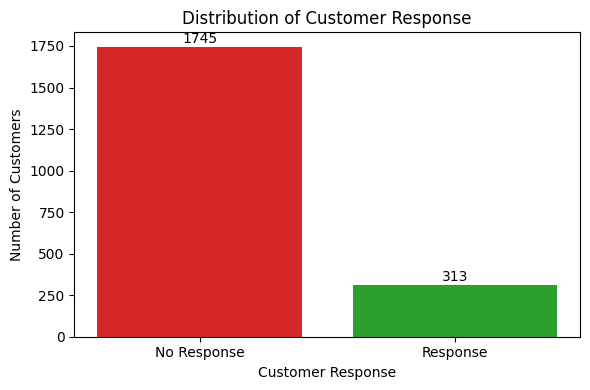

In [ ]:
df["Response_Label"] = df["Response"].map({0: "No Response", 1: "Response"})
response_counts = df["Response_Label"].value_counts()

response_counts = response_counts[["No Response", "Response"]]

plt.figure(figsize=(6, 4))
bars = plt.bar(
    response_counts.index,
    response_counts.values,
    color=["#d62728", "#2ca02c"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.title("Distribution of Customer Response")
plt.xlabel("Customer Response")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("chapter4_figures/Figure_4_1_Distribution_of_Customer_Response.png", dpi=300)
plt.show()

4.2.2 Demographic and Behavioural Patterns by Customer Response

Figure 4.2: Boxplot Comparison of Recency, Total Spending, Income, and Age by Customer Response

/tmp/ipykernel_1194/48557097.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot(
/tmp/ipykernel_1194/48557097.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(
/tmp/ipykernel_1194/48557097.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(
/tmp/ipykernel_1194/48557097.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(
/tmp/ipykernel_1194/48557097.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of 

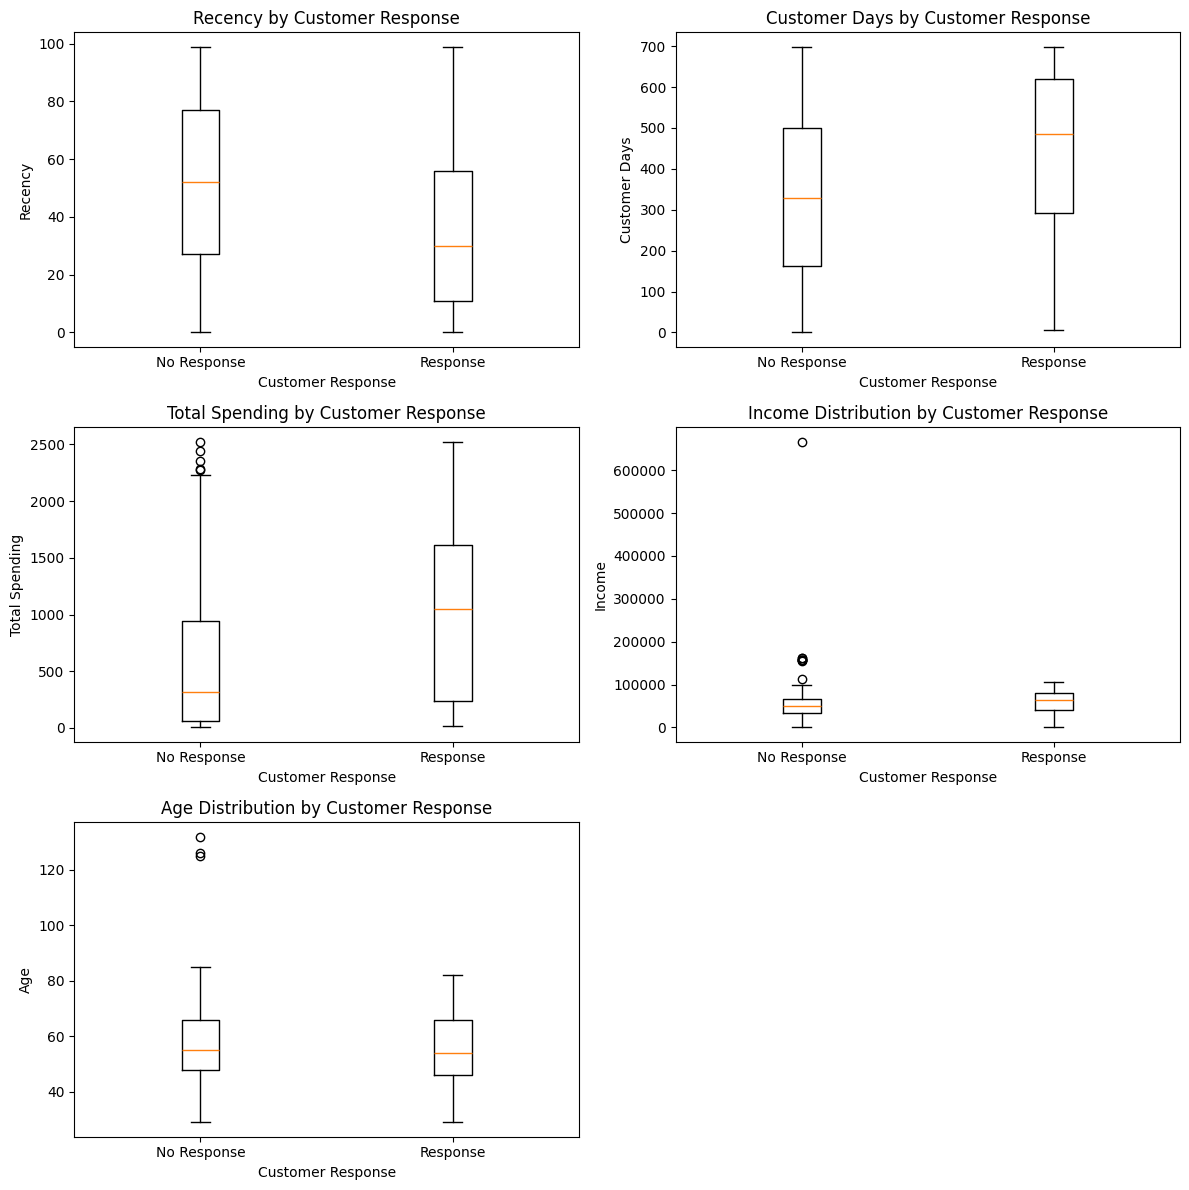

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# 1. Recency
recency_data = [
    df[df["Response"] == 0]["Recency"].dropna(),
    df[df["Response"] == 1]["Recency"].dropna()
]

axes[0, 0].boxplot(
    recency_data,
    labels=["No Response", "Response"]
)

axes[0, 0].set_title("Recency by Customer Response")
axes[0, 0].set_xlabel("Customer Response")
axes[0, 0].set_ylabel("Recency")


# 2. Customer_Days
customer_days_data = [
    df[df["Response"] == 0]["Customer_Days"].dropna(),
    df[df["Response"] == 1]["Customer_Days"].dropna()
]

axes[0, 1].boxplot(
    customer_days_data,
    labels=["No Response", "Response"]
)

axes[0, 1].set_title("Customer Days by Customer Response")
axes[0, 1].set_xlabel("Customer Response")
axes[0, 1].set_ylabel("Customer Days")


# 3. Total_Spend
spend_data = [
    df[df["Response"] == 0]["Total_Spend"].dropna(),
    df[df["Response"] == 1]["Total_Spend"].dropna()
]

axes[1, 0].boxplot(
    spend_data,
    labels=["No Response", "Response"]
)

axes[1, 0].set_title("Total Spending by Customer Response")
axes[1, 0].set_xlabel("Customer Response")
axes[1, 0].set_ylabel("Total Spending")


# 4. Income
income_data = [
    df[df["Response"] == 0]["Income"].dropna(),
    df[df["Response"] == 1]["Income"].dropna()
]

axes[1, 1].boxplot(
    income_data,
    labels=["No Response", "Response"]
)

axes[1, 1].set_title("Income Distribution by Customer Response")
axes[1, 1].set_xlabel("Customer Response")
axes[1, 1].set_ylabel("Income")


# 5. Age
age_data = [
    df[df["Response"] == 0]["Age"].dropna(),
    df[df["Response"] == 1]["Age"].dropna()
]

axes[2, 0].boxplot(
    age_data,
    labels=["No Response", "Response"]
)

axes[2, 0].set_title("Age Distribution by Customer Response")
axes[2, 0].set_xlabel("Customer Response")
axes[2, 0].set_ylabel("Age")


# Remove empty subplot
fig.delaxes(axes[2, 1])

plt.tight_layout()

plt.savefig(
    "chapter4_figures/Figure_4_2_Boxplot_Comparison_by_Customer_Response.png",
    dpi=300
)

plt.show()

4.2.3 Purchase Channels by Customer Response

Figure 4.3: Purchase Channels by Customer Response

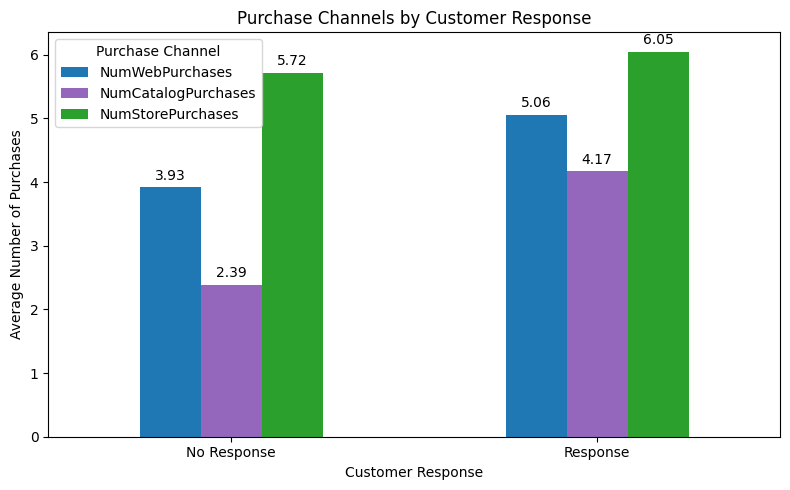

In [ ]:
purchase_cols = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]

purchase_channel_mean = df.groupby("Response_Label")[purchase_cols].mean()

purchase_channel_mean = purchase_channel_mean.loc[["No Response", "Response"]]

ax = purchase_channel_mean.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#1f77b4", "#9467bd", "#2ca02c"]
)

plt.title("Purchase Channels by Customer Response")
plt.xlabel("Customer Response")
plt.ylabel("Average Number of Purchases")
plt.xticks(rotation=0)
plt.legend(
    ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"],
    title="Purchase Channel"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.savefig("chapter4_figures/Figure_4_8_Purchase_Channels_by_Customer_Response.png", dpi=300)
plt.show()

Figure 4.4: Total Campaigns Accepted by Customer Response

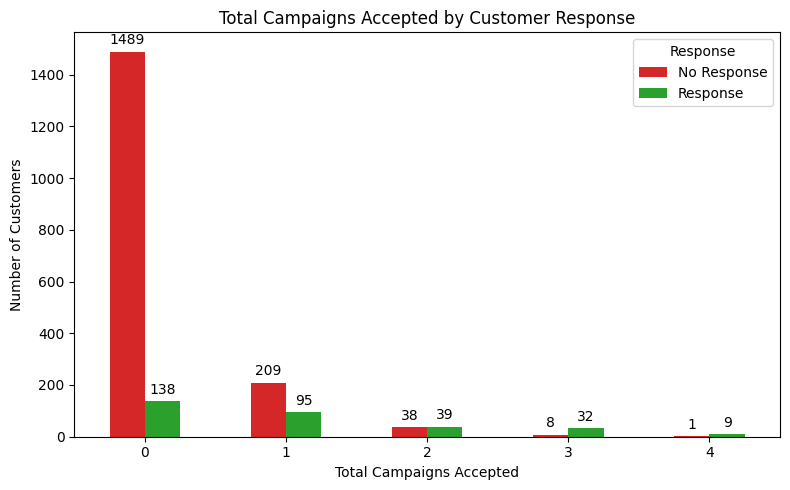

In [ ]:
campaign_response = pd.crosstab(df["Total_Campaign_Accepted"], df["Response_Label"])

campaign_response = campaign_response[["No Response", "Response"]]

ax = campaign_response.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#d62728", "#2ca02c"]
)

plt.title("Total Campaigns Accepted by Customer Response")
plt.xlabel("Total Campaigns Accepted")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Response")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.savefig("chapter4_figures/Figure_4_9_Total_Campaigns_Accepted_by_Customer_Response.png", dpi=300)
plt.show()

Figure 4.5: ROC-AUC Comparison by Model

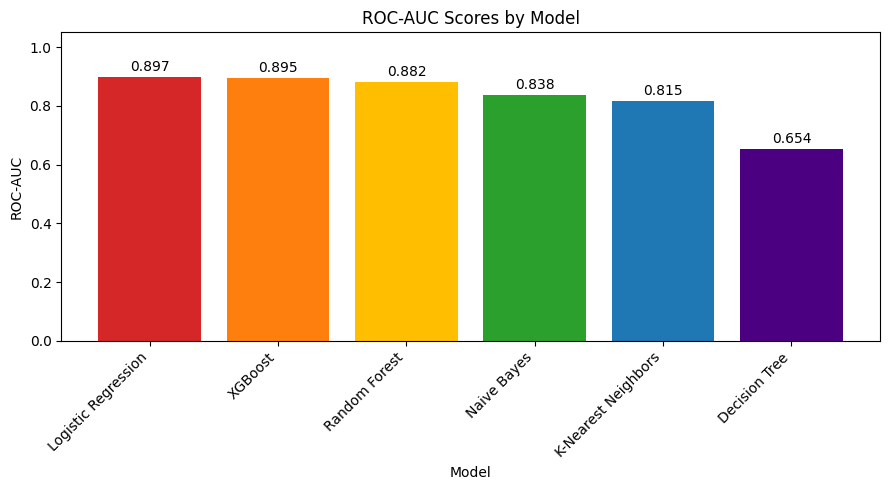

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_auc_score

roc_auc_data = {
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "K-Nearest Neighbors",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_nb),
        roc_auc_score(y_test, y_prob_knn),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
}

roc_auc_df = pd.DataFrame(roc_auc_data)

roc_auc_df = roc_auc_df.sort_values(by="ROC-AUC", ascending=False)

colors = [
    "#d62728",  # red
    "#ff7f0e",  # orange
    "#ffbf00",  # yellow
    "#2ca02c",  # green
    "#1f77b4",  # blue
    "#4B0082"   # purple
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    roc_auc_df["Model"],
    roc_auc_df["ROC-AUC"],
    color=colors[:len(roc_auc_df)]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("ROC-AUC Scores by Model")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("Figure_4_ROC_AUC_Comparison.png", dpi=300, bbox_inches="tight")

plt.show()

Overall Evaluation Metrics Comparison

Final Model Comparison Results:
                 Model   ROC-AUC  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.897231  0.902913   0.783333  0.500000  0.610390
1              XGBoost  0.895221  0.898058   0.754098  0.489362  0.593548
2        Random Forest  0.882045  0.870550   0.718750  0.244681  0.365079
3          Naive Bayes  0.837563  0.865696   0.720000  0.191489  0.302521
4  K-Nearest Neighbors  0.815231  0.883495   0.720000  0.382979  0.500000
5        Decision Tree  0.654083  0.825243   0.423913  0.414894  0.419355


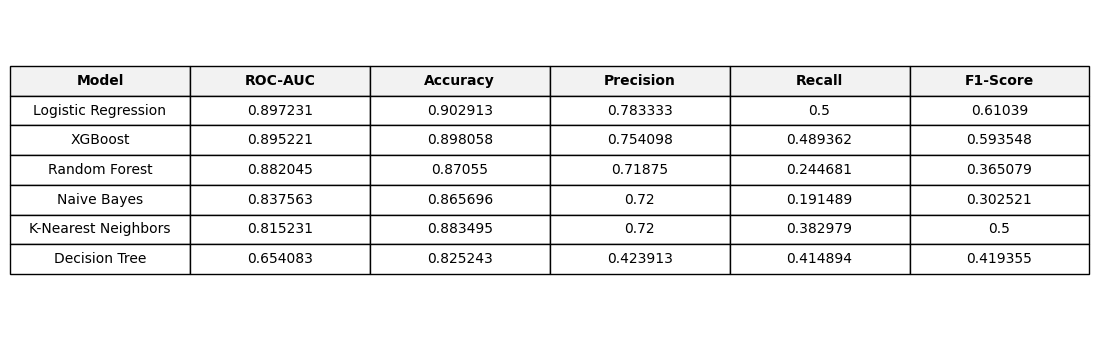

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

results_data = {
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "K-Nearest Neighbors",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_nb),
        roc_auc_score(y_test, y_prob_knn),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_nb, zero_division=0),
        precision_score(y_test, y_pred_knn, zero_division=0),
        precision_score(y_test, y_pred_dt, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0),
        precision_score(y_test, y_pred_xgb, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_nb, zero_division=0),
        recall_score(y_test, y_pred_knn, zero_division=0),
        recall_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_xgb, zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_nb, zero_division=0),
        f1_score(y_test, y_pred_knn, zero_division=0),
        f1_score(y_test, y_pred_dt, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_xgb, zero_division=0)
    ]
}

results_df = pd.DataFrame(results_data)

results_df = results_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

results_df_display = results_df.copy()
results_df_display[["ROC-AUC", "Accuracy", "Precision", "Recall", "F1-Score"]] = results_df_display[
    ["ROC-AUC", "Accuracy", "Precision", "Recall", "F1-Score"]
].round(6)

print("Final Model Comparison Results:")
print(results_df_display)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.axis("off")

table = ax.table(
    cellText=results_df_display.values,
    colLabels=results_df_display.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(1)
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#f2f2f2")

plt.tight_layout()
plt.savefig("chapter4_figures/Table_4_1_Overall_Evaluation_Metrics_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()